# LoRA Implementation for Qwen2.5-Instruct


In [2]:
import sys
import os
import torch
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from torch.utils.data import DataLoader, TensorDataset
from accelerate import Accelerator
from IPython.display import display, Markdown

# Add parent directory to the path
sys.path.append(os.path.abspath('..'))

# Import project modules
from src.utils.lora import (LoRALinear, apply_lora_to_model, process_sequences, 
                      train_lora, evaluate_model, create_train_val_loaders)
from src.utils.flops_calculator import calculate_lora_flops
from qwen import load_qwen

# Configure plotting
plt.style.use('mystyle.mplstyle')

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

## 1. Examining the Qwen2.5-Instruct Model Architecture

First, let's examine the structure of the Qwen2.5-Instruct model to understand where to apply LoRA.

In [3]:
# Load the Qwen2.5-Instruct model
model, tokenizer = load_qwen()

# Print model architecture summary
print(model)

# Print config to see key parameters
print(model.config)

Sliding Window Attention is enabled but not implemented for `sdpa`; unexpected results may be encountered.


Qwen2ForCausalLM(
  (model): Qwen2Model(
    (embed_tokens): Embedding(151936, 896)
    (layers): ModuleList(
      (0-23): 24 x Qwen2DecoderLayer(
        (self_attn): Qwen2Attention(
          (q_proj): Linear(in_features=896, out_features=896, bias=True)
          (k_proj): Linear(in_features=896, out_features=128, bias=True)
          (v_proj): Linear(in_features=896, out_features=128, bias=True)
          (o_proj): Linear(in_features=896, out_features=896, bias=False)
        )
        (mlp): Qwen2MLP(
          (gate_proj): Linear(in_features=896, out_features=4864, bias=False)
          (up_proj): Linear(in_features=896, out_features=4864, bias=False)
          (down_proj): Linear(in_features=4864, out_features=896, bias=False)
          (act_fn): SiLU()
        )
        (input_layernorm): Qwen2RMSNorm((896,), eps=1e-06)
        (post_attention_layernorm): Qwen2RMSNorm((896,), eps=1e-06)
      )
    )
    (norm): Qwen2RMSNorm((896,), eps=1e-06)
    (rotary_emb): Qwen2RotaryEmbe

### Identifying the Query and Value Projection Layers

Let's look at the structure of one of the attention blocks to identify the query (`q_proj`) and value (`v_proj`) projection layers that we need to modify with LoRA.

In [4]:
# Examine the first layer's attention block structure
attention_block = model.model.layers[0].self_attn
print(f"Attention block structure:\n{attention_block}\n")

# Print details of q_proj and v_proj layers
q_proj = attention_block.q_proj
v_proj = attention_block.v_proj

print(f"q_proj: {q_proj}")
print(f"q_proj shape: in={q_proj.in_features}, out={q_proj.out_features}")
print(f"q_proj.weight.shape: {q_proj.weight.shape}")
print(f"q_proj.bias: {q_proj.bias is not None}\n")

print(f"v_proj: {v_proj}")
print(f"v_proj shape: in={v_proj.in_features}, out={v_proj.out_features}")
print(f"v_proj.weight.shape: {v_proj.weight.shape}")
print(f"v_proj.bias: {v_proj.bias is not None}")

Attention block structure:
Qwen2Attention(
  (q_proj): Linear(in_features=896, out_features=896, bias=True)
  (k_proj): Linear(in_features=896, out_features=128, bias=True)
  (v_proj): Linear(in_features=896, out_features=128, bias=True)
  (o_proj): Linear(in_features=896, out_features=896, bias=False)
)

q_proj: Linear(in_features=896, out_features=896, bias=True)
q_proj shape: in=896, out=896
q_proj.weight.shape: torch.Size([896, 896])
q_proj.bias: True

v_proj: Linear(in_features=896, out_features=128, bias=True)
v_proj shape: in=896, out=128
v_proj.weight.shape: torch.Size([128, 896])
v_proj.bias: True


In [5]:
# Reset the model
model, tokenizer = load_qwen()

# Count number of trainable parameters before LoRA
orig_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Number of trainable parameters before LoRA: {orig_params:,}")

# Apply LoRA with rank 4 (medium value to start)
lora_rank = 4
model = apply_lora_to_model(model, r=lora_rank)

# Count number of trainable parameters after LoRA
lora_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Number of trainable parameters after LoRA: {lora_params:,}")

2025-03-26 16:48:17,489 - src.utils.lora - INFO - Using default target modules: ['q_proj', 'v_proj']
2025-03-26 16:48:17,491 - src.utils.lora - INFO - Applying LoRA with rank 4 and alpha 4
2025-03-26 16:48:17,492 - src.utils.lora - INFO - Original trainable parameters: 151,936
2025-03-26 16:48:17,499 - src.utils.lora - INFO - Applied LoRA with rank 4 to 48 ['q_proj', 'v_proj'] modules
2025-03-26 16:48:17,499 - src.utils.lora - INFO - Trainable parameters: 422,272 (original: 151,936, ratio: 2.779275)


Number of trainable parameters before LoRA: 151,936
Number of trainable parameters after LoRA: 422,272


In [11]:
print(model)

Qwen2ForCausalLM(
  (model): Qwen2Model(
    (embed_tokens): Embedding(151936, 896)
    (layers): ModuleList(
      (0-23): 24 x Qwen2DecoderLayer(
        (self_attn): Qwen2Attention(
          (q_proj): LoRALinear(
            (original_linear): Linear(in_features=896, out_features=896, bias=True)
          )
          (k_proj): Linear(in_features=896, out_features=128, bias=True)
          (v_proj): LoRALinear(
            (original_linear): Linear(in_features=896, out_features=128, bias=True)
          )
          (o_proj): Linear(in_features=896, out_features=896, bias=False)
        )
        (mlp): Qwen2MLP(
          (gate_proj): Linear(in_features=896, out_features=4864, bias=False)
          (up_proj): Linear(in_features=896, out_features=4864, bias=False)
          (down_proj): Linear(in_features=4864, out_features=896, bias=False)
          (act_fn): SiLU()
        )
        (input_layernorm): Qwen2RMSNorm((896,), eps=1e-06)
        (post_attention_layernorm): Qwen2RMSNorm(

### Understanding LoRA Parameter Adaptation

In our implementation, we're applying LoRA to the query (q_proj) and value (v_proj) projection layers in each of the attention blocks. Here's what this means:

1. We're freezing the original model weights (the pre-trained parameters)
2. For each q_proj and v_proj layer, we're adding two trainable matrices:
   - A: A low-rank matrix of shape (r, hidden_dim)
   - B: A low-rank matrix of shape (out_dim, r)
3. During the forward pass, we compute: original_output + (input @ A.T @ B.T) * (alpha/r)

This allows us to adapt the model with far fewer parameters than full fine-tuning.

## 2. Data Preparation


In [6]:
# Load the preprocessed data
with open('../data/formatted_train.pkl', 'rb') as f:
    train_texts = pickle.load(f)

# Separate training and validation data
train_texts, val_texts = train_texts[:700], train_texts[700:]

# Print sample data
print(f"Number of training sequences: {len(train_texts)}")
print(f"Number of validation sequences: {len(val_texts)}")
print(f"\nSample training sequence:\n{train_texts[0][:100]}...")

Number of training sequences: 700
Number of validation sequences: 100

Sample training sequence:
1.71,1.93;1.54,1.71;1.46,1.49;1.45,1.29;1.52,1.12;1.64,0.99;1.84,0.89;2.09,0.82;2.41,0.78;2.79,0.78;...


## 3. Testing LoRA on Small Dataset

In [7]:
# Create small subset for initial testing
train_small = train_texts[:20]
val_small = val_texts[:5]

# Process sequences with reasonable context length
max_ctx_length = 128  # Start with a smaller context length for testing
batch_size = 8

# Create dataloaders with small test set
train_loader_small, val_loader_small = create_train_val_loaders(
    train_small, val_small, tokenizer, max_ctx_length, batch_size
)

print(f"Small training loader: {len(train_loader_small)} batches")
print(f"Small validation loader: {len(val_loader_small)} batches")

# Setup optimizer with appropriate learning rate
learning_rate = 1e-4
optimizer = torch.optim.AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=learning_rate
)

# Setup accelerator for efficient training
accelerator = Accelerator()
model, optimizer, train_loader_small, val_loader_small = accelerator.prepare(
    model, optimizer, train_loader_small, val_loader_small
)

2025-03-26 16:48:18,360 - src.utils.lora - INFO - Creating data loaders with max_ctx_length=128, batch_size=8
2025-03-26 16:48:18,361 - src.utils.lora - INFO - Processing 20 training sequences
2025-03-26 16:48:18,361 - src.utils.lora - INFO - Processing 20 sequences with max_length=128, stride=64
Processing sequences: 100%|██████████| 20/20 [00:00<00:00, 523.15it/s]
2025-03-26 16:48:18,455 - src.utils.lora - INFO - Created 320 total chunks from 20 sequences
2025-03-26 16:48:18,458 - src.utils.lora - INFO - Processing 5 validation sequences
2025-03-26 16:48:18,459 - src.utils.lora - INFO - Processing 5 sequences with max_length=128, stride=128
Processing sequences: 100%|██████████| 5/5 [00:00<00:00, 613.94it/s]
2025-03-26 16:48:18,468 - src.utils.lora - INFO - Created 40 total chunks from 5 sequences
2025-03-26 16:48:18,470 - src.utils.lora - INFO - Created train loader with 320 samples and val loader with 40 samples


Small training loader: 40 batches
Small validation loader: 5 batches


In [8]:
# Train for a small number of steps to verify overfitting capability
max_steps = 20
eval_steps = 10
output_dir = "../results/lora/small_test"

# Train the model
train_stats = train_lora(
    model=model,
    train_loader=train_loader_small,
    optimizer=optimizer,
    accelerator=accelerator,
    max_steps=max_steps,
    eval_loader=val_loader_small,
    eval_steps=eval_steps,
    logging_steps=10,
    output_dir=output_dir,
    model_name="lora_small_test"
)


2025-03-26 16:48:19,084 - src.utils.lora - INFO - Training with batch_size=8, seq_length=128
2025-03-26 16:48:19,086 - src.utils.lora - INFO - Output directory: ../results/lora/small_test
2025-03-26 16:48:19,086 - src.utils.lora - INFO - Using actual LoRA rank=4 for FLOPS calculation
2025-03-26 16:48:19,086 - src.utils.flops_calculator - INFO - Calculating LoRA FLOPs for 48 modules with rank 4, over 20 steps in training mode
2025-03-26 16:48:19,087 - src.utils.flops_calculator - INFO - Training FLOPs: forward=1,092,674,464,768, backward=2,185,348,929,536, total=3,278,023,394,304
2025-03-26 16:48:19,087 - src.utils.flops_calculator - INFO - LoRA overhead: 0.06% FLOPs per step compared to standard training
2025-03-26 16:48:19,088 - src.utils.flops_calculator - INFO - Total LoRA training FLOPs: 65,602,734,673,920 for 20 steps
2025-03-26 16:48:19,088 - src.utils.lora - INFO - Estimated FLOPs per step: 65,602,734,673,920
2025-03-26 16:48:19,089 - src.utils.lora - INFO - Starting training fo

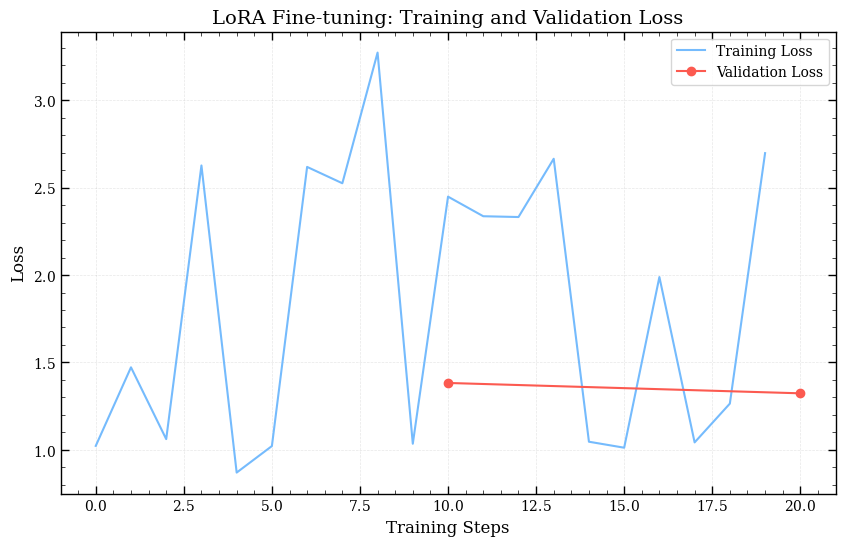

In [9]:
# Plot training and validation loss
plt.figure(figsize=(10, 6))
plt.plot(train_stats['train_losses'], label='Training Loss')
plt.plot(range(10, max_steps+10, eval_steps), train_stats['eval_losses'], 'o-', label='Validation Loss')
plt.xlabel('Training Steps')
plt.ylabel('Loss')
plt.title('LoRA Fine-tuning: Training and Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 4. FLOPS Calculation

Let's calculate the FLOPS used in the small test to ensure we're tracking our computation budget properly.

In [10]:
import pandas as pd

# Calculate FLOPS for the small test
small_test_flops = calculate_lora_flops(
    batch_size=batch_size,
    seq_length=max_ctx_length,
    r=lora_rank,
    steps=max_steps,
    model_size="0.5B"  # Using default 0.5B model size
)

# Format a summary table
flops_summary = pd.DataFrame({
    'Metric': ['LoRA Rank', 'Batch Size', 'Sequence Length', 'Training Steps',
               'FLOPS per step (standard)', 'FLOPS per step (LoRA)', 'Total FLOPS per step',
               'Total FLOPS used', 'Budget Usage'],
    'Value': [
        lora_rank,
        batch_size, 
        max_ctx_length,
        max_steps,
        f"{small_test_flops['standard_per_step']:,.0f}",
        f"{small_test_flops['lora_additional_per_step']:,.0f}",
        f"{small_test_flops['combined_per_step']:,.0f}",
        f"{small_test_flops['combined_total']:,.2e}",
        f"{small_test_flops['combined_total']/1e17:.2%}"
    ]
})

flops_summary

2025-03-26 16:50:44,845 - src.utils.flops_calculator - INFO - Calculating LoRA FLOPs for 48 modules with rank 4, over 20 steps in training mode
2025-03-26 16:50:44,847 - src.utils.flops_calculator - INFO - Training FLOPs: forward=1,092,674,464,768, backward=2,185,348,929,536, total=3,278,023,394,304
2025-03-26 16:50:44,848 - src.utils.flops_calculator - INFO - LoRA overhead: 0.06% FLOPs per step compared to standard training
2025-03-26 16:50:44,849 - src.utils.flops_calculator - INFO - Total LoRA training FLOPs: 65,602,734,673,920 for 20 steps


,Metric,Value
0,LoRA Rank,4
1,Batch Size,8
2,Sequence Length,128
3,Training Steps,20
4,FLOPS per step (standard),"3,278,023,394,304"
5,FLOPS per step (LoRA),"2,113,339,392"
6,Total FLOPS per step,"3,280,136,733,696"
7,Total FLOPS used,6.56e+13
8,Budget Usage,0.07%
